# ML-03 — Frame Your Lane as an ML Task

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Maryam-Shile/flyrank_ml_internship/blob/main/work/notebooks/w02_ml_task_framing.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My lane as an ML task (type)

*Classification, clustering, ranking, or scoring — which one, and why?*

The task is ultimately a clustering task. Fot the diagnostic tool, it uses unsupervised machine learning in grouping low performance pages based on similar features which can be easily used in examining the possible cause of failure.

## 2. Target or proxy

*What would you predict? Where does that label come from — observed outcome or a defined rule?*

There is no real target here. An engineered feature called perfomance score is used to select low performing contents which will be further clustered to investigate failure mode, based on the data the team can access.
All performance metrics are eliminated from this final layer to prevent leakage because the performance score is like an aggregate of the these scores.

Why cant we have a target?
perfomance score is an aggregate of all perfomance metrics in this dataset. Is it possible to that content-specific data explains why the pages are not perfoming well?

First we will try to find out using a logistic regression.

In [209]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


In [210]:
df = pd.read_csv('/content/info_data.csv')
df.head()

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,days_with_impressions_rank,days_with_sessions_rank,ctr_rank,engagement_rate_rank,scroll_rate_rank,ai_traffic_pct_rank,avg_position_rank,performance_score,perfomance_label,trend_pct_rank
0,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,0.809370,0.602785,0.468755,0.356948,0.612860,0.468059,0.307948,53.005026,good,0.291453
1,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,0.809370,0.650218,0.527444,0.356948,0.779332,0.468059,0.108826,56.159524,good,0.264776
2,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,0.809370,0.875573,0.587525,0.356948,0.745197,0.468059,0.068849,63.934734,good,0.494752
3,content_9a34b442b552,client_8722616204,0.0,0.00,LOW,0.00,keyword article,informational,3059.0,20810.0,...,0.127038,0.078271,0.214070,0.356948,0.184839,0.468059,0.752740,26.228918,not good,0.065569
4,content_5e6c160719bc,client_6208ef0f77,0.0,0.00,LOW,0.00,keyword article,informational,3807.0,24228.0,...,0.502118,0.920279,0.527444,0.885263,0.537231,0.468059,0.060953,65.907300,good,0.282363


In [211]:
df.iloc[0]

,0
content_id,content_a1fb4e703a9e
client_id,client_4e07408562
search_volume,90.0
competition,0.01
competition_level,LOW
cpc,0.05
content_type,keyword article
main_intent,informational
word_count,2481.0
char_count,15562.0


Data Cleaning
remove all performance metrics except the agregated scores to prevent leakage



In [212]:
performance_cols = ['impressions_90d', 'clicks_90d', 'pageviews_90d',
       'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d',
       'days_with_impressions', 'days_with_sessions', 'ctr', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'trend_pct', 'avg_position', 'trend_direction']

for col in df.columns:
  if '_rank' in col:
    performance_cols.append(col)

df = df.drop(columns = performance_cols)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17235 entries, 0 to 17234
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content_id              17235 non-null  object 
 1   client_id               17235 non-null  object 
 2   search_volume           17092 non-null  float64
 3   competition             17092 non-null  float64
 4   competition_level       17092 non-null  object 
 5   cpc                     17092 non-null  float64
 6   content_type            17235 non-null  object 
 7   main_intent             17235 non-null  object 
 8   word_count              13169 non-null  float64
 9   char_count              13169 non-null  float64
 10  provider_used           5399 non-null   object 
 11  model_used              14443 non-null  object 
 12  content_age_days        17235 non-null  int64  
 13  days_since_last_update  17235 non-null  int64  
 14  performance_score       17235 non-null

Dropping main_intent because this data is only for informational content, so no variations here

In [213]:
df = df.drop(columns = ['main_intent'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17235 entries, 0 to 17234
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content_id              17235 non-null  object 
 1   client_id               17235 non-null  object 
 2   search_volume           17092 non-null  float64
 3   competition             17092 non-null  float64
 4   competition_level       17092 non-null  object 
 5   cpc                     17092 non-null  float64
 6   content_type            17235 non-null  object 
 7   word_count              13169 non-null  float64
 8   char_count              13169 non-null  float64
 9   provider_used           5399 non-null   object 
 10  model_used              14443 non-null  object 
 11  content_age_days        17235 non-null  int64  
 12  days_since_last_update  17235 non-null  int64  
 13  performance_score       17235 non-null  float64
 14  perfomance_label        17235 non-null

Correct the typo

In [214]:
df.rename(columns = {'perfomance_label':'performance_label'}, inplace = True)
df

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,word_count,char_count,provider_used,model_used,content_age_days,days_since_last_update,performance_score,performance_label
0,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,2481.0,15562.0,NaN,gemini-3-flash-preview,445,25,53.005026,good
1,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,3515.0,23643.0,NaN,gemini-2.5-flash,141,20,56.159524,good
2,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,2803.0,17469.0,NaN,gemini-3-flash-preview,263,14,63.934734,good
3,content_9a34b442b552,client_8722616204,0.0,0.00,LOW,0.00,keyword article,3059.0,20810.0,google,gemini-3-flash-preview,90,20,26.228918,not good
4,content_5e6c160719bc,client_6208ef0f77,0.0,0.00,LOW,0.00,keyword article,3807.0,24228.0,google,gemini-3-flash-preview,90,20,65.907300,good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17230,content_9bb9a0584cae,client_8527a891e2,210.0,0.00,LOW,0.00,keyword article,1446.0,9001.0,NaN,gpt-4o-mini,146,8,22.708201,not good
17231,content_e859812ce999,client_19581e27de,10.0,0.20,LOW,0.00,keyword article,NaN,NaN,NaN,NaN,148,104,70.104974,good
17232,content_b7fa2d76e5ae,client_4e07408562,70.0,0.00,LOW,0.00,keyword article,2501.0,15617.0,NaN,gemini-3-flash-preview,280,14,47.517201,good
17233,content_23dce6a656e6,client_e29c9c180c,140.0,0.99,HIGH,0.22,keyword article,1508.0,9735.0,NaN,gemini-2.5-flash,348,20,18.803598,not good


In [215]:
df.shape

(17235, 15)

In [216]:
df.columns

Index(['content_id', 'client_id', 'search_volume', 'competition',
       'competition_level', 'cpc', 'content_type', 'word_count', 'char_count',
       'provider_used', 'model_used', 'content_age_days',
       'days_since_last_update', 'performance_score', 'performance_label'],
      dtype='object')

Select feature and target variables

In [217]:
X = df.drop(columns = ['performance_label', 'performance_score']).copy()
y = df['performance_label'].copy()

In [218]:
cat_cols = ['content_id', 'client_id', 'competition_level', 'content_type', 'provider_used', 'model_used']
num_cols = ['search_volume', 'competition', 'cpc', 'word_count', 'char_count', 'content_age_days', 'days_since_last_update']

len(cat_cols) + len(num_cols)


13

Inspect to understand structure, distribution and find missing values

In [219]:
for i in cat_cols:
  print(f'{i}: {X[i].nunique()}')
  print()

content_id: 17235

client_id: 31

competition_level: 3

content_type: 2

provider_used: 2

model_used: 5



In [220]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17235 entries, 0 to 17234
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content_id              17235 non-null  object 
 1   client_id               17235 non-null  object 
 2   search_volume           17092 non-null  float64
 3   competition             17092 non-null  float64
 4   competition_level       17092 non-null  object 
 5   cpc                     17092 non-null  float64
 6   content_type            17235 non-null  object 
 7   word_count              13169 non-null  float64
 8   char_count              13169 non-null  float64
 9   provider_used           5399 non-null   object 
 10  model_used              14443 non-null  object 
 11  content_age_days        17235 non-null  int64  
 12  days_since_last_update  17235 non-null  int64  
dtypes: float64(5), int64(2), object(6)
memory usage: 1.7+ MB


In [221]:
for j in num_cols:
  print(f'{j}: {X[j].describe()}')
  print()

search_volume: count    17092.00000
mean       181.01802
std       1794.64879
min          0.00000
25%          0.00000
50%          0.00000
75%         20.00000
max      74000.00000
Name: search_volume, dtype: float64

competition: count    17092.000000
mean         0.064296
std          0.175978
min          0.000000
25%          0.000000
50%          0.000000
75%          0.010000
max          1.000000
Name: competition, dtype: float64

cpc: count    17092.000000
mean         0.307775
std          1.877918
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        100.360000
Name: cpc, dtype: float64

word_count: count    13169.000000
mean      3286.597540
std       1389.088853
min        424.000000
25%       2568.000000
50%       2944.000000
75%       3733.000000
max       9179.000000
Name: word_count, dtype: float64

char_count: count     13169.000000
mean      21712.112613
std        9384.049228
min        3143.000000
25%       16855.000000

Majority of search volume, competition and cpc, majority of which are understood to be placeholders for unavailable data. These will be changed to nan.

In [222]:
search_volume = X[X['search_volume'] == 0.0]
search_volume.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9757 entries, 1 to 17234
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content_id              9757 non-null   object 
 1   client_id               9757 non-null   object 
 2   search_volume           9757 non-null   float64
 3   competition             9757 non-null   float64
 4   competition_level       9757 non-null   object 
 5   cpc                     9757 non-null   float64
 6   content_type            9757 non-null   object 
 7   word_count              8621 non-null   float64
 8   char_count              8621 non-null   float64
 9   provider_used           3944 non-null   object 
 10  model_used              9145 non-null   object 
 11  content_age_days        9757 non-null   int64  
 12  days_since_last_update  9757 non-null   int64  
dtypes: float64(5), int64(2), object(6)
memory usage: 1.0+ MB


In [223]:
X['search_volume'] = X['search_volume'].replace(0, np.nan)
X['competition'] = X['competition'].replace(0, np.nan)
X['cpc'] = X['cpc'].replace(0, np.nan)




Both Search_volume and cpc are skewed and need to normalized. log1p is used due to extreme long tails and the presence of zeros which returns an a -inf when logged.

In [224]:
X['search_volume'] = np.log1p(X['search_volume'])
X['cpc'] = np.log1p(X['cpc'])

Ensure that there are no multicollinearity among the feature variables.

In [225]:
X[num_cols].corr()

,search_volume,competition,cpc,word_count,char_count,content_age_days,days_since_last_update
search_volume,1.000000,-0.080635,-0.032930,0.047852,0.026663,0.212147,-0.016007
competition,-0.080635,1.000000,0.239879,-0.138619,-0.126384,-0.123987,0.032149
cpc,-0.032930,0.239879,1.000000,-0.066685,-0.041568,0.013431,-0.017487
word_count,0.047852,-0.138619,-0.066685,1.000000,0.961276,0.008269,0.403871
char_count,0.026663,-0.126384,-0.041568,0.961276,1.000000,-0.026884,0.368908
content_age_days,0.212147,-0.123987,0.013431,0.008269,-0.026884,1.000000,0.014621
days_since_last_update,-0.016007,0.032149,-0.017487,0.403871,0.368908,0.014621,1.000000


In [226]:
X_features = X.drop(columns = ['word_count'], axis = 1).copy()

content and client id are simply identifiers and are not particularly relevant to this model. However, client id has the potential of causing leakage because there are only about 30 unique clients. If the model trains on a client data and still finds the same client under test, it could lead to data leakage. More on this subsequently

In [227]:
client_group = X['client_id']
content_group = X['content_id']

In [228]:
X_features = X_features.drop(columns = ['client_id', 'content_id'], axis = 1)

In [229]:
X_features

,search_volume,competition,competition_level,cpc,content_type,char_count,provider_used,model_used,content_age_days,days_since_last_update
0,4.510860,0.01,LOW,0.048790,keyword article,15562.0,NaN,gemini-3-flash-preview,445,25
1,NaN,NaN,LOW,NaN,keyword article,23643.0,NaN,gemini-2.5-flash,141,20
2,NaN,NaN,LOW,NaN,keyword article,17469.0,NaN,gemini-3-flash-preview,263,14
3,NaN,NaN,LOW,NaN,keyword article,20810.0,google,gemini-3-flash-preview,90,20
4,NaN,NaN,LOW,NaN,keyword article,24228.0,google,gemini-3-flash-preview,90,20
...,...,...,...,...,...,...,...,...,...,...
17230,5.351858,NaN,LOW,NaN,keyword article,9001.0,NaN,gpt-4o-mini,146,8
17231,2.397895,0.20,LOW,NaN,keyword article,NaN,NaN,NaN,148,104
17232,4.262680,NaN,LOW,NaN,keyword article,15617.0,NaN,gemini-3-flash-preview,280,14
17233,4.948760,0.99,HIGH,0.198851,keyword article,9735.0,NaN,gemini-2.5-flash,348,20


In [230]:
cat_cols = ['competition_level', 'content_type', 'provider_used', 'model_used']
num_cols = ['search_volume', 'competition', 'cpc', 'char_count', 'content_age_days', 'days_since_last_update']

len(cat_cols) + len(num_cols)


10

Set up the pipeline for preprocessing and modelling

In [231]:
num_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
cat_pipeline = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num_pipeline', num_pipeline, num_cols),
        ('cat_pipeline', cat_pipeline, cat_cols)
    ])

pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression())
    ]
)

Instead of train_test_spit, we need to split our data using a shuffle technique in  way that one client does not show in the training and testing data at the same time


In [232]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_features, y, groups = client_group))

X_train, X_test = X_features.iloc[train_idx].copy(), X_features.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()

In [233]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13542 entries, 1 to 17234
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   search_volume           5469 non-null   float64
 1   competition             3579 non-null   float64
 2   competition_level       13493 non-null  object 
 3   cpc                     2168 non-null   float64
 4   content_type            13542 non-null  object 
 5   char_count              10096 non-null  float64
 6   provider_used           4261 non-null   object 
 7   model_used              10750 non-null  object 
 8   content_age_days        13542 non-null  int64  
 9   days_since_last_update  13542 non-null  int64  
dtypes: float64(4), int64(2), object(4)
memory usage: 1.1+ MB


In [234]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3693 entries, 0 to 17233
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   search_volume           1866 non-null   float64
 1   competition             1001 non-null   float64
 2   competition_level       3599 non-null   object 
 3   cpc                     583 non-null    float64
 4   content_type            3693 non-null   object 
 5   char_count              3073 non-null   float64
 6   provider_used           1138 non-null   object 
 7   model_used              3693 non-null   object 
 8   content_age_days        3693 non-null   int64  
 9   days_since_last_update  3693 non-null   int64  
dtypes: float64(4), int64(2), object(4)
memory usage: 317.4+ KB


train and evaluate the classification model

In [235]:
pipeline.fit(X_train, y_train)
predictions = pipeline.predict(X_test)
prediction_probabilities = pipeline.predict_proba(X_test)
print()
print(classification_report(y_test, predictions))


              precision    recall  f1-score   support

        good       0.50      0.93      0.65      1817
    not good       0.61      0.10      0.18      1876

    accuracy                           0.51      3693
   macro avg       0.56      0.52      0.41      3693
weighted avg       0.56      0.51      0.41      3693



In [236]:
pipeline.predict_proba(X_test)

array([[0.85844373, 0.14155627],
       [0.66604304, 0.33395696],
       [0.66466662, 0.33533338],
       ...,
       [0.66760213, 0.33239787],
       [0.7779652 , 0.2220348 ],
       [0.57188842, 0.42811158]])

In [237]:
y = df['performance_score'].copy()

In [238]:
cat_cols = ['competition_level', 'content_type', 'provider_used', 'model_used']
num_cols = ['search_volume', 'competition', 'cpc', 'char_count', 'content_age_days', 'days_since_last_update']

len(cat_cols) + len(num_cols)

10

In [239]:
num_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
cat_pipeline = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num_pipeline', num_pipeline, num_cols),
        ('cat_pipeline', cat_pipeline, cat_cols)
    ])

param_dist = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [10, 16, 20, None],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__max_features': ['sqrt', 'log2', None]
}

pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('rf', RandomForestRegressor(random_state=42))
    ])

search = RandomizedSearchCV(
    pipeline,
    param_dist,
    n_iter=25,          # sample 25 combos instead of all 243
    cv=3,               # 3 folds instead of 5
    scoring='neg_mean_absolute_error',
    verbose=2,
    n_jobs=-1,
    random_state=42)

In [240]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_features, y, groups = client_group))

X_train, X_test = X_features.iloc[train_idx].copy(), X_features.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()

In [241]:
search.fit(X_train, y_train)
print("Best Parameters found:", search.best_params_)
print("Best Negative MSE Score:", search.best_score_)

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best Parameters found: {'rf__n_estimators': 200, 'rf__min_samples_split': 10, 'rf__min_samples_leaf': 1, 'rf__max_features': 'log2', 'rf__max_depth': 20}
Best Negative MSE Score: -10.456068177295975


In [242]:
prediction = search.predict(X_test)
print(mean_absolute_error(y_test, prediction))
print(r2_score(y_test, prediction))

13.274682388760366
0.09243415729985383


In [243]:
y.describe()

,performance_score
count,17235.000000
mean,49.670521
std,16.380500
min,18.803598
25%,36.574226
50%,47.615899
75%,62.218043
max,92.045649


## 3. Success metric

*One metric you can defend. What number means 'good'?*

The analysis above clearly shows that content performance is somewhat independent of the contnt characteristics. However, the performance scores can be used to separate low performing contents and analyse them further for better insights.

In [244]:
df.columns

Index(['content_id', 'client_id', 'search_volume', 'competition',
       'competition_level', 'cpc', 'content_type', 'word_count', 'char_count',
       'provider_used', 'model_used', 'content_age_days',
       'days_since_last_update', 'performance_score', 'performance_label'],
      dtype='object')

In [245]:
low_cut_off = df['performance_score'].quantile(0.4)
new_data = df[df['performance_score'] >= low_cut_off]

client_group = new_data['client_id']
content_group = new_data['content_id']

new_data = new_data.drop(columns = ['content_id', 'client_id', 'word_count'])

In [246]:
new_data['search_volume'] = new_data['search_volume'].replace(0, np.nan)
new_data['competition'] = new_data['competition'].replace(0, np.nan)
new_data['cpc'] = new_data['cpc'].replace(0, np.nan)


new_data['search_volume'] = np.log1p(new_data['search_volume'])
new_data['cpc'] = np.log1p(X['cpc'])

In [247]:
num_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
cat_pipeline = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num_pipeline', num_pipeline, num_cols),
        ('cat_pipeline', cat_pipeline, cat_cols)
    ])
processed_data = preprocessor.fit_transform(new_data)

In [248]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

def calculate_elbow_inertia(data, max_k =10):
  inertia = []
  k_range = range(1, max_k + 1)

  for i in k_range:
    kmeans = KMeans(n_clusters = i, random_state = 42)
    kmeans.fit_predict(data)
    inertia.append(kmeans.inertia_)
  return list(k_range), inertia



In [249]:
k_range, inertia = calculate_elbow_inertia(processed_data, 10)


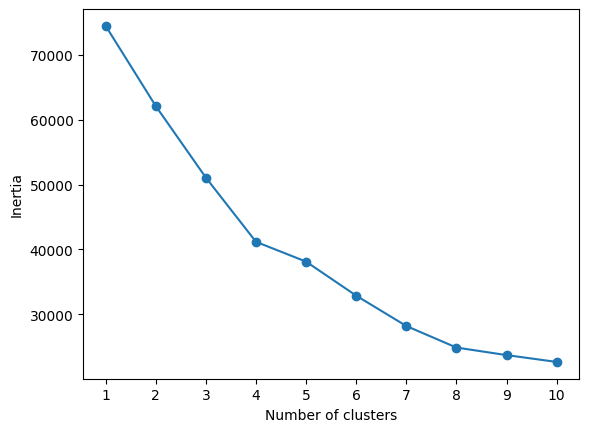

In [250]:
plt.plot(k_range, inertia, '-o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.show()

In [251]:
model = KMeans(n_clusters = 5, random_state = 42)
model.fit(processed_data)
labels = model.predict(processed_data)

new_data['labels'] = labels

new_data

,search_volume,competition,competition_level,cpc,content_type,char_count,provider_used,model_used,content_age_days,days_since_last_update,performance_score,performance_label,labels
0,4.510860,0.01,LOW,0.047637,keyword article,15562.0,NaN,gemini-3-flash-preview,445,25,53.005026,good,3
1,NaN,NaN,LOW,NaN,keyword article,23643.0,NaN,gemini-2.5-flash,141,20,56.159524,good,0
2,NaN,NaN,LOW,NaN,keyword article,17469.0,NaN,gemini-3-flash-preview,263,14,63.934734,good,0
4,NaN,NaN,LOW,NaN,keyword article,24228.0,google,gemini-3-flash-preview,90,20,65.907300,good,4
5,NaN,NaN,LOW,NaN,keyword article,NaN,NaN,NaN,257,104,47.917926,good,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17228,NaN,NaN,LOW,NaN,keyword article,38349.0,NaN,gemini-3-flash-preview,229,104,68.368976,good,1
17229,2.397895,NaN,LOW,NaN,keyword article,19294.0,google,gemini-3-flash-preview,139,20,76.826556,good,4
17231,2.397895,0.20,LOW,NaN,keyword article,NaN,NaN,NaN,148,104,70.104974,good,1
17232,4.262680,NaN,LOW,NaN,keyword article,15617.0,NaN,gemini-3-flash-preview,280,14,47.517201,good,3


## 4. The unit of analysis, as a real dataframe

*Load your lane's slice and show it: one row = one what?*

In [252]:
numerical_summary = new_data.groupby('labels')[num_cols].mean()
numerical_summary

,search_volume,competition,cpc,char_count,content_age_days,days_since_last_update
labels,,,,,,
0,2.905538,0.155159,0.256774,18602.130858,200.317783,35.382448
1,3.086517,0.139673,0.268937,37426.600605,231.417773,104.179204
2,4.124345,0.605709,0.784987,16215.075067,286.270115,44.986590
3,4.149599,0.101092,0.268415,17759.636727,457.638721,26.878997
4,3.226178,0.149516,0.258233,19974.660959,110.218798,22.569635


In [253]:
for i in numerical_summary.columns:
  numerical_summary[i] = numerical_summary[i].rank(pct = True)

<Axes: ylabel='labels'>

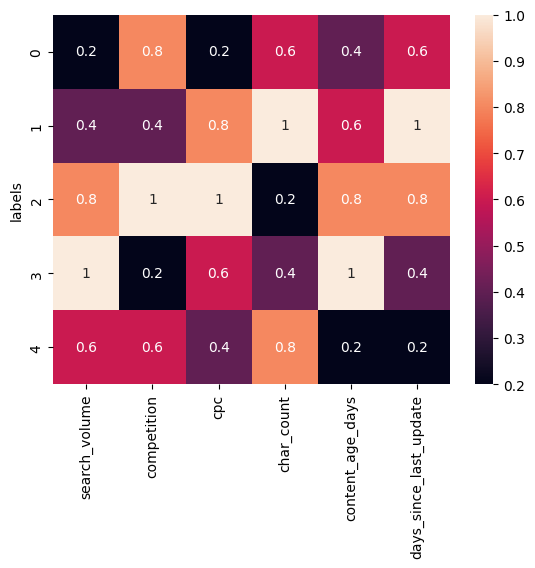

In [254]:
import seaborn as sns
sns.heatmap(numerical_summary, annot = True)

Result and discussion

archtype 0: These contents are not being searched frequently, possibly because the topic is unpopular as the competition and cpc are low as well.

archtype 1: Slightly higher search volume than the first archtype but competition is low and what is most striking is the length of the content and last time the content was updated.

archtype 2: High search volume in a competitive niche and that is evident with the cpc. This is worthy of review because of the risk of spending on a content noone is actually interacting with. It should be compared with competitor's content to see how it may be improved.

archtype 3: Moderate search volume in a low competition niche. This represents the group of contents that are old but are still valuable. It is hinting that the content itself needs to be refreshed for value.

archtype 4: These are the youngest in the group. And their low performance may be due to lack of data on their activity. They may be given some time to gather data for better insights.

## 5. Why ML beats a fixed rule here

*What makes the pattern too messy for an if-statement?*
One performance metric cannot tell the full story of the content. By first aggregating perfomance metrics and extracting the low performance contents, Using an unsupervised learning model has made it possible to properly group into possible archtypes. These archtypes offers a plausible explanation into various failure modes.

In [255]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.